In [21]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os
from pathlib import Path

In [22]:
# Define the API key for US Census Bureau. Keys are free to obtain from https://api.census.gov/data/key_signup.html
UScensus_key='722729cfa99e33f0f76a6c4385beb4a6394f1728'

## US Census: Finding variable code (ie B01003_001E for total population)
When you’re trying to web-scrape a Census variable, the safest way is to check the official variables.json metadata file (for example: https://api.census.gov/data/2024/acs/acs1/subject/variables.json) and search for keywords to find the exact variable code.    
It’s also totally fine to start from the Census website table itself: just look at the table name, identify which row and column your data lives in, and then map that position to the corresponding variable code.

## Function to fetch multiple variables from United States Census Bureau

In [23]:
def fetch_msa_variable_acs1_recent_n_years(var_code: list, var_name: list, api_key: str, n_years: int, max_lookback: int = 10):
    """
    Fetch one ACS1 variable for all MSAs for the most recent n available years.
    Census null sentinel values (-666666666, -999999999, -888888888) are replaced with NaN.
    """
    CENSUS_NULL_SENTINELS = {-666666666, -999999999, -888888888}

    current_year = datetime.today().year
    dfs = []
    collected = 0

    for year in range(current_year, current_year - max_lookback, -1):

        if collected >= n_years:
            break

        if var_code.startswith("S"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/subject"
        elif var_code.startswith("B"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1"
        elif var_code.startswith("D"):
            base_url = f"https://api.census.gov/data/{year}/acs/acs1/profile"
        else:
            raise ValueError("Unsupported variable code prefix")

        params = {
            "get": f"NAME,{var_code}",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": api_key
        }

        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            continue

        data = response.json()
        if len(data) <= 1:
            continue

        df = pd.DataFrame(data[1:], columns=data[0])
        if var_code not in df.columns:
            continue

        df = df.rename(columns={
            var_code: var_name,
            "NAME": "msa_name",
            "metropolitan statistical area/micropolitan statistical area": "msa_code"
        })

        df[var_name] = pd.to_numeric(df[var_name], errors="coerce")
        # ── BUG FIX: Replace Census null sentinel values with NaN ──
        df[var_name] = df[var_name].replace(CENSUS_NULL_SENTINELS, np.nan)
        df["year"] = year

        dfs.append(df[["msa_code", "msa_name", "year", var_name]])
        collected += 1

    if not dfs:
        raise RuntimeError("No available data found")

    return pd.concat(dfs, ignore_index=True)


In [24]:
# collect useful variables their codes to this dictionary.
variables_acs1 = {"Total_Population": "B01003_001E",
                  "Laborforce_Population": "DP03_0002E",
                  "Employed": "DP03_0004E",
                  "Median_Household_Income": "S1903_C03_001E",
                  "Median_House_Value": "B25077_001E",
                  "Total_Housing_Units": "B25002_001E",
                  "House_Occupied": "B25002_002E",
                  "House_Vacant": "B25002_003E",
                  "Median_Gross_Rent": "B25064_001E",
                  "5_to_9_units": "DP04_0011E",
                  "10_to_19_units":"DP04_0012E",
                  "20_or_more_units":"DP04_0013E"
                 }

In [25]:
# Model instantiation: Fetch ACS1 variables for all MSAs for the most recent n+1 available years.
# n+1 years of data is needed to construct growh factors, i.e. population growth
dfs = []
for var_name, var_code in variables_acs1.items():
  df = fetch_msa_variable_acs1_recent_n_years(var_code = var_code, var_name = var_name, api_key = UScensus_key, n_years = 5+1)
  dfs.append(df)

In [26]:
msa_features_recent_5_years = reduce(lambda left, right: pd.merge(
        left, right, on=["msa_code", "msa_name", "year"], how="outer"), dfs)
msa_features_recent_5_years = msa_features_recent_5_years.sort_values(by=['msa_code', 'year'])

msa_features_recent_5_years['Total_Multi_Units']=msa_features_recent_5_years['5_to_9_units']\
+msa_features_recent_5_years['10_to_19_units']+msa_features_recent_5_years['20_or_more_units']

# Filter out MSAs with a total population over 300,000 by the most recent year
population_requirement=300000

most_recent_year = msa_features_recent_5_years['year'].max()
eligible_msa = msa_features_recent_5_years.loc[
    (msa_features_recent_5_years['year'] == most_recent_year) &
    (msa_features_recent_5_years['Total_Population'] >= population_requirement) &
    (msa_features_recent_5_years['msa_name'].str.endswith('Metro Area')),
    'msa_code'].unique()

msa_features_recent_5_years = msa_features_recent_5_years[
    msa_features_recent_5_years['msa_code'].isin(eligible_msa)]

# Print out the number of MSAs achieving population requirement
print(f"By the year {most_recent_year}, {msa_features_recent_5_years['msa_code'].nunique()} \
MSAs have a population of over {population_requirement}.")

By the year 2024, 173 MSAs have a population of over 300000.


In [27]:
# Note that the U.S. Census Bureau did not release standard 2020 American Community Survey (ACS) 1-year estimates
# because the COVID-19 pandemic severely disrupted data collection, leading to low response rates and high nonresponse bias.
# If it is extremely necessary to use consecutive data including 2020, we shall switch from acs1 to acs5.
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='16980']

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,House_Vacant,Median_Gross_Rent,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units
512,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2018,9497790,5089589,4792415,70760,247800,3858653,3538101,320552,1110,294938.0,168767.0,512310.0,976015.0
513,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,9457867,5059338,4796817,75379,253800,3869464,3539174,330290,1139,285616.0,168737.0,538489.0,992842.0
514,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,9510390,5063933,4663627,78166,281100,3956161,3670416,285745,1225,282262.0,176507.0,556612.0,1015381.0
515,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,9442159,5097936,4833113,82914,301300,3968906,3726266,242640,1294,304321.0,180421.0,572979.0,1057721.0
510,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,9262559,5053959,4791844,87071,316500,3911902,3671659,240243,1390,291526.0,181012.0,565152.0,1037690.0
511,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,9406924,5137844,4840603,90770,339700,3924020,3690402,233618,1469,282946.0,186917.0,588696.0,1058559.0


## Joining US Census data with tax data (Updated)
While US census data are collected on MSA scale, tax data are collected on different scales, using **Gemini**:    
- Residential Effective Rate: State Averaged
- Commercial Effective Rate: proxy of the Largest City of that State

To merge the two datasets in a consistent manner, we assign each MSA the state code corresponding to the state in which its largest principal city (the 1st city in MSA title) is located. We then use this state code to merge the MSA-level Census data with the state-level tax data.

Example:    
(1) **MSA = 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area'**   
----> State Code = 'PA'     
----> Principle city of the state = 'Philadelphia'  
----> MSA US Census data Joined by *Pennsylvania Average Residential Effective Tax Rate* and *Philadelphia Commercial Effective Tax Rate*

(2) **MSA = 'Akron, OH Metro Area'**   
----> State Code = 'OH'   
----> Principle city of the state = 'Columbus'   
----> MSA US Census data Joined by *Ohio Average Residential Effective Tax Rate* and *Columbus Commercial Effective Tax Rate*

In [28]:
# Load the tax data and calculate the difference in effective tax rates between hotels and multifamily properties
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
tax_file = project_root / "assets" / "spreadsheets" / "State Property Tax Comparison_ Hotels vs. Multifamily_New.xlsx"

df_tax = pd.read_excel(tax_file, sheet_name="Tax new")
df_tax['Diff_Effective_Rate'] = df_tax['Hotel Effective Rate'] - df_tax['Multifamily Effective Rate']
df_tax.head(10)

,State Code,State,MSA (Core County),Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,AZ,Arizona,Maricopa,0.014450,0.009320,0.00513
1,AL,Alabama,Birmingham,0.014500,0.007250,0.00725
2,AK,Alaska,Anchorage,0.016145,0.016145,0.00000
3,AR,Arkansas,Little Rock,0.014040,0.014040,0.00000
4,CA,California,Los Angeles,0.012500,0.012500,0.00000
5,CO,Colorado,Denver,0.019900,0.005540,0.01436
6,CT,Connecticut,Hartford,0.048300,0.048300,0.00000
7,DE,Delaware,New Castle,0.020300,0.020300,0.00000
8,FL,Florida,Miami-Dade,0.019988,0.019988,0.00000
9,GA,Georgia,Fulton,0.016532,0.016532,0.00000


In [29]:
# extracting the state code where the largest principal city of the MSA is located
def extract_principal_state(msa_name):
    match =  msa_name.split(', ')[1].split(' ')[0].split('-')[0]
    return match
# extracting the largest principal city of each MSA
def extract_principal_city(msa_name):
    return msa_name.split(',')[0].split('-')[0]

msa_features_recent_5_years['State Code']=msa_features_recent_5_years['msa_name'].apply(extract_principal_state)
msa_features_recent_5_years['Principal_City']=msa_features_recent_5_years['msa_name'].apply(extract_principal_city)

# merging two datasets
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_tax[['State', 'State Code', 'Hotel Effective Rate',
       'Multifamily Effective Rate',
       'Diff_Effective_Rate']], on='State Code', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna() # only 1 Puerto Rican MSA is deleted

msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,5_to_9_units,10_to_19_units,20_or_more_units,Total_Multi_Units,State Code,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,12975.0,13435.0,21032.0,47442.0,OH,Akron,Ohio,0.0406,0.0406,0.0
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,16498.0,12021.0,21692.0,50211.0,OH,Akron,Ohio,0.0406,0.0406,0.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,14485.0,10987.0,19882.0,45354.0,OH,Akron,Ohio,0.0406,0.0406,0.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,13528.0,11199.0,23140.0,47867.0,OH,Akron,Ohio,0.0406,0.0406,0.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,11945.0,12604.0,22320.0,46869.0,OH,Akron,Ohio,0.0406,0.0406,0.0


## Joining Cap Rate data (data collected using Gemini)

In [30]:
# from google.colab import files
# uploaded = files.upload()

In [31]:
cap_file = project_root / "assets" / "spreadsheets" / "Hotel_vs_MF_Cap_Rate_Spread_Analysis.xlsx"
OPEX_file = project_root / "assets" / "spreadsheets" / "State OPEX Assumptions for Housing.xlsx"
df_cap = pd.read_excel(cap_file, sheet_name="Cap Rate Spread Analysis", usecols="A:H", header=3, nrows=50)
df_OER = pd.read_excel(OPEX_file)
df_cap['Cap Spread'] = df_cap['Hotel Cap Rate'] - df_cap['MF Cap Rate']
df_OER = df_OER.rename(columns={'Default OPEX %':'OPEX%'})
df_cap.tail()

,Rank,State,Hotel Cap Rate,MF Cap Rate,SPREAD (bps),Spread %,Key Conversion Market,Conversion Thesis,Cap Spread
45,46,Colorado,0.100,0.0650,350,0.0350,Denver (DIA/I-25),Denver DIA corridor + I-25 economy hotels → ap...,0.0350
46,47,Texas,0.100,0.0650,350,0.0350,"DFW, Houston, Austin, San Antonio",DFW/Houston massive economy hotel inventory → ...,0.0350
47,48,Florida,0.095,0.0625,325,0.0325,"Orlando, Tampa, Jacksonville",Orlando I-Drive + Tampa corridor → apartments....,0.0325
48,49,New York,0.090,0.0575,325,0.0325,"NYC, Buffalo",NYC hotel-to-housing conversions ALREADY ACTIV...,0.0325
49,50,Hawaii,0.080,0.0500,300,0.0300,Hawaii,Spread too narrow. Budget hotels still generat...,0.0300


In [32]:
df_OER.head()

,State Code,State,OPEX%,"Primary Cost Drivers (Taxes, Insurance, Climate, Age)"
0,AL,Alabama,0.48,High coastal insurance risk pool; aging plumbi...
1,AK,Alaska,0.46,"Extreme winterization, heating utilities, and ..."
2,AZ,Arizona,0.44,Rising insurance; extreme summer heat accelera...
3,AR,Arkansas,0.45,Moderate taxes; aging housing stock requiring ...
4,CA,California,0.40,Prop 13 caps reassessment risk; extremely high...


#### Hotel Conversion Relevance Score — State Rating Mapping

We convert state letter ratings into a monotonic [0,1] score to preserve rank order while allowing non-linear spacing between tiers. The mapping is intentionally non-equidistant: lower tiers (F, D-, D, D+) receive steeper penalties to reflect higher execution and policy risk, while top tiers (A-, A, A+) receive an additional premium for stronger conversion feasibility.

| State Rating | Hotel Conversion Relevance Score |
|---|---|
| A+ | 1.00 |
| A | 0.90 |
| A- | 0.84 |
| B+ | 0.78 |
| B | 0.66 |
| B- | 0.61 |
| C+ | 0.57 |
| C | 0.52 |
| C- | 0.40 |
| D+ | 0.33 |
| D | 0.25 |
| D- | 0.12 |
| F | 0.00 |

**Design Rationale:**
- Non-equidistant spacing: steeper penalties in the lower tier (F→D-→D→D+) and premium rewards in the upper tier (A-→A→A+) reflect differential execution and policy risk.
- Middle tiers (B-, B, B+, C-, C, C+) are spaced more smoothly to avoid over-separating states with broadly similar conditions.
- All scores are mapped to [0,1] and will be standardized (z-score) alongside other factors for seamless integration into the weighted index aggregation framework.
This design keeps the variable interpretable, directionally consistent with our ranking framework, and directly compatible with downstream standardization and weighted index aggregation.

In [33]:
df_Conversion_Category = pd.read_excel(cap_file, sheet_name="Regulatory Environment", usecols="A:C", header=3, nrows=50)

# define a mapping from Conversion Category to a numerical score representing Hotel_Conversion_Relevance
rating_to_score = {
    'A+': 1.00,
    'A': 0.90,
    'A-': 0.84,
    'B+': 0.78,
    'B': 0.66,
    'B-': 0.61,
    'C+': 0.57,
    'C': 0.52,
    'C-': 0.40,
    'D+': 0.33,
    'D': 0.25,
    'D-': 0.12,
    'F': 0.00
}

# map Conversion Category to Hotel_Conversion_Relevance
df_Conversion_Category['Hotel_Conversion_Relevance'] = df_Conversion_Category['Conversion Category'].map(rating_to_score)

df_Conversion_Category.head()


,State,Conversion Feasibility (Zoning / Tenant Protection / Regulatory),Conversion Category,Hotel_Conversion_Relevance
0,Alabama,[A] VERY FAVORABLE — No rent control. 7-day ev...,A,0.90
1,Alaska,[C] NEUTRAL — No rent control. Landlord-friend...,C,0.52
2,Arizona,[A] VERY FAVORABLE — No rent control statewide...,A,0.90
3,Arkansas,[A] VERY FAVORABLE — No rent control. No limit...,A,0.90
4,California,[F] VERY UNFAVORABLE — Statewide rent control ...,F,0.00


In [34]:
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_cap[['State', 'Hotel Cap Rate', 'MF Cap Rate', 'Cap Spread']], on='State', how='left')

msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_OER[['State Code', 'OPEX%']], on='State Code', how='left')

msa_features_recent_5_years=pd.merge(msa_features_recent_5_years,
        df_Conversion_Category[['State', 'Hotel_Conversion_Relevance']], on='State', how='left')

msa_features_recent_5_years=msa_features_recent_5_years.dropna()
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,Principal_City,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap Rate,MF Cap Rate,Cap Spread,OPEX%,Hotel_Conversion_Relevance
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,Akron,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,Akron,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,Akron,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,Akron,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,Akron,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78


In [35]:
df_2024 = msa_features_recent_5_years[msa_features_recent_5_years['year']==2024]

df_2024=df_2024[['msa_code','msa_name', 'OPEX%']].sort_values('OPEX%', ascending = False)
df_2024.head()


,msa_code,msa_name,OPEX%
452,29180,"Lafayette, LA Metro Area",0.53
860,43340,"Shreveport-Bossier City, LA Metro Area",0.53
602,35380,"New Orleans-Metairie, LA Metro Area",0.53
83,12940,"Baton Rouge, LA Metro Area",0.53
614,35840,"North Port-Bradenton-Sarasota, FL Metro Area",0.52


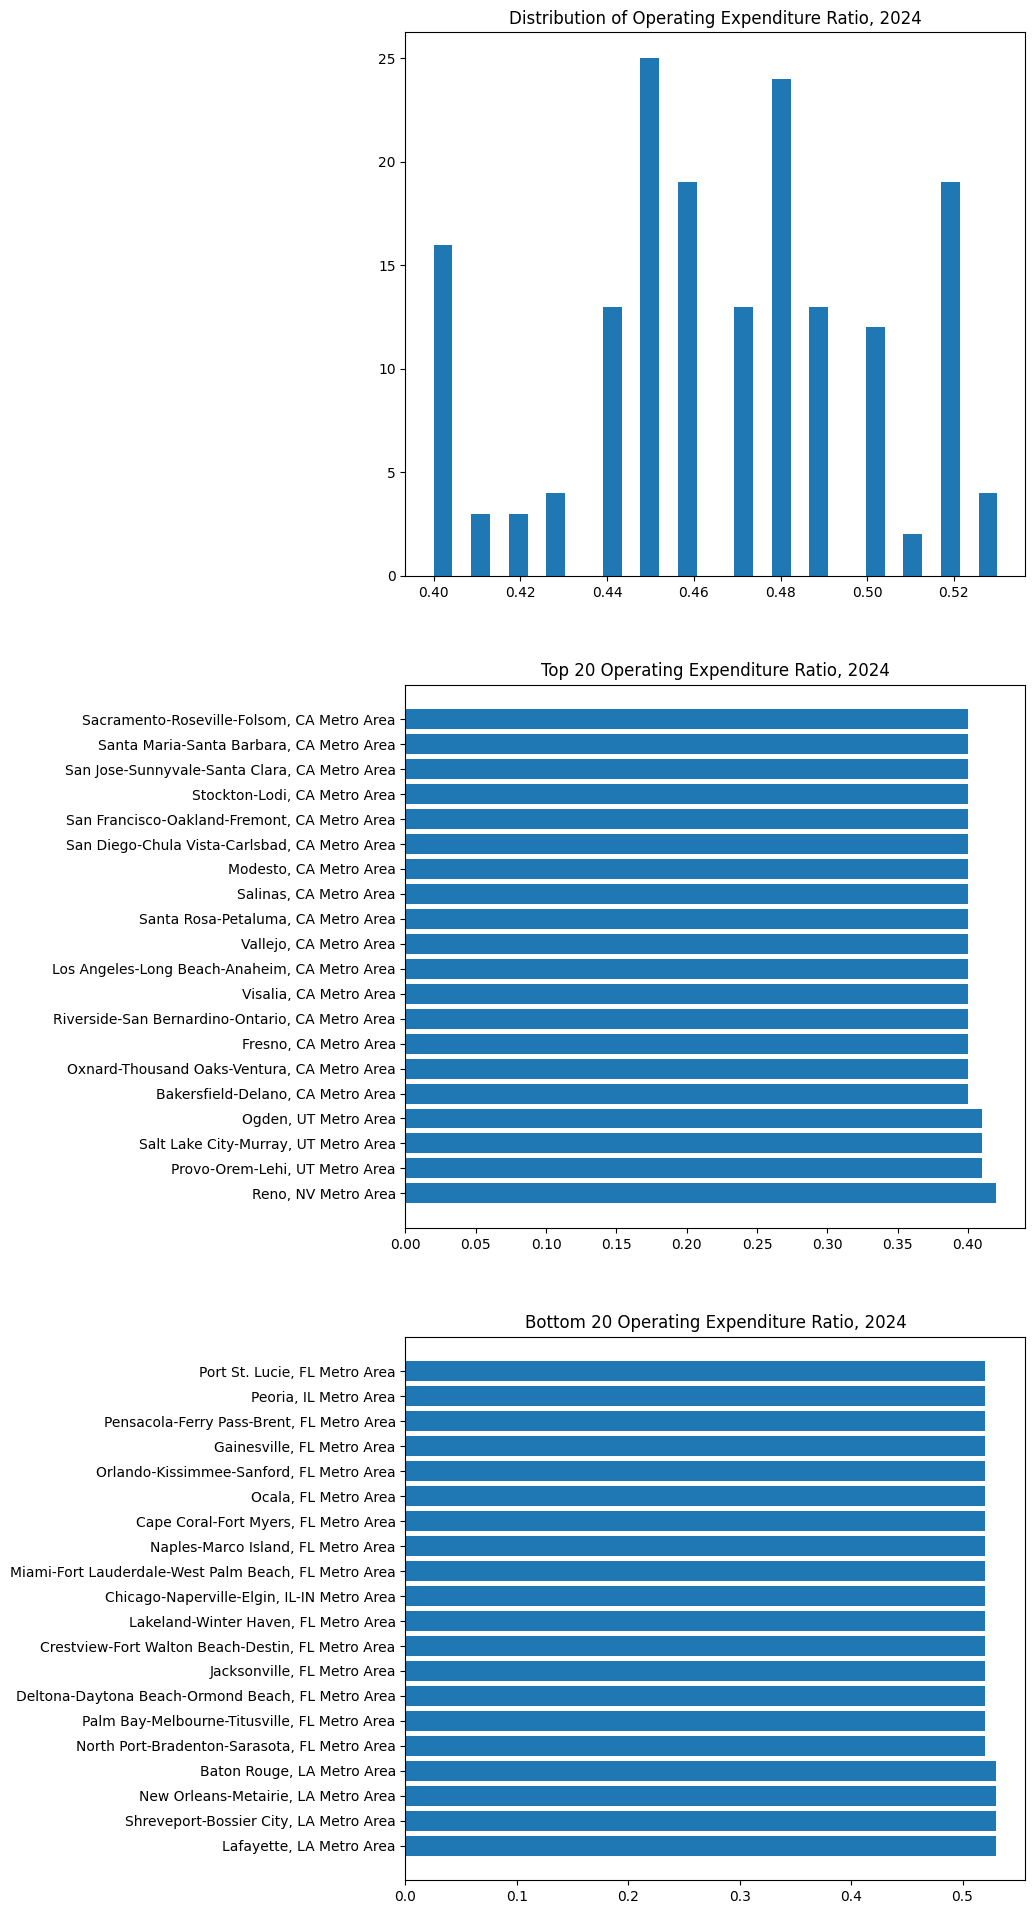

In [36]:
fig=plt.figure(figsize=(8,24))

ax1=fig.add_subplot(3,1,1)
ax1.hist(df_2024['OPEX%'], bins=30)
ax1.set_title("Distribution of Operating Expenditure Ratio, 2024")

ax2=fig.add_subplot(3,1,2)
ax2.barh(df_2024['msa_name'][-20:], df_2024['OPEX%'][-20:])
ax2.set_title("Top 20 Operating Expenditure Ratio, 2024")

ax3=fig.add_subplot(3,1,3)
ax3.barh(df_2024['msa_name'][:20], df_2024['OPEX%'][:20])
ax3.set_title("Bottom 20 Operating Expenditure Ratio, 2024")



plt.show()

## Joining ESG data (past 5 available years: 2019; 2021-2024)
Data source: RESNET (Residential Energy Services Network)  

Only PDF available. Need to manually convert PDF into Excel    
(free PDF conversion tool: https://www.ilovepdf.com/)


HERS Index: The Home Energy Rating System (HERS) Index is the industry standard by which a home’s energy efficiency is measured. It’s also the nationally recognized system for inspecting and calculating a home’s energy performance.
https://www.hersindex.com/hers-index/understanding-hers-index/

A certified RESNET Home Energy Rater assesses the energy efficiency of a home, assigning it a relative performance score (the HERS® Index Score). **The lower the number, the more energy efficient the home.** A home built to 2006 energy efficiency standards scores 100.

A home with a HERS® Index Score of 70 is 30% more energy efficient than the RESNET Reference Home.
A home with a HERS® Index Score of 130 is 30% less energy efficient than the RESNET Reference Home.*



In [37]:
#uploaded = files.upload()

In [38]:
years=msa_features_recent_5_years['year'].unique().tolist() #years=[2018, 2019, 2021, 2022, 2023, 2024]
HER_dfs=[]
HER_columns = ['State', 'Number of Homes HERS Rated', 'Average HERS Index Score']
for year in years[1:]: # # the earliest year (2018) is solely for computing demographic growth factors, so we skip it here
  file_path = project_root / "assets" / "spreadsheets" / f"{year}-HERS-Activity-by-State.xlsx"
  df = pd.read_excel(file_path, skiprows=1, usecols=[0,1,2])
  df.columns=HER_columns
  df['year']=year
  HER_dfs.append(df)

HER_dfs=pd.concat(HER_dfs, ignore_index=True)

In [39]:
msa_features_recent_5_years['State'] = (msa_features_recent_5_years['State'].replace('Washington, D.C.', 'D.C.'))
# Adding Average HERS Index Score to large dataset
msa_features_recent_5_years=pd.merge(msa_features_recent_5_years, HER_dfs[['State', 'year','Average HERS Index Score']],
                                     on=['State', 'year'], how='left')
msa_features_recent_5_years.head()

,msa_code,msa_name,year,Total_Population,Laborforce_Population,Employed,Median_Household_Income,Median_House_Value,Total_Housing_Units,House_Occupied,...,State,Hotel Effective Rate,Multifamily Effective Rate,Diff_Effective_Rate,Hotel Cap Rate,MF Cap Rate,Cap Spread,OPEX%,Hotel_Conversion_Relevance,Average HERS Index Score
0,10420,"Akron, OH Metro Area",2018,704845,382261,360654,60019,155500,315526,287044,...,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78,NaN
1,10420,"Akron, OH Metro Area",2019,703479,374176,353676,57158,157200,316217,285647,...,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78,62.0
2,10420,"Akron, OH Metro Area",2021,700015,362579,343062,63367,181700,317783,292156,...,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78,61.0
3,10420,"Akron, OH Metro Area",2022,697627,368407,353226,66652,199400,318589,294908,...,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78,61.0
4,10420,"Akron, OH Metro Area",2023,698398,375374,359014,70125,216000,321142,298193,...,Ohio,0.0406,0.0406,0.0,0.1075,0.07,0.0375,0.49,0.78,61.0


# Factor Creation

10 factors are constructed to build 6 indices. ESG factor is currently left aside due to a lack of credibility.
<br><br>
## Economic Index:


*   Employment Rate:

$$Employment~Rate = \frac{Employed}{Laborforce~Population}$$
<br>
*   Employment Growth:

$$Employment~Growth = \frac{Employed_t - Employed_{t-1}}{Employed_{t-1}}$$
<br>

*   Population Growth:

$$Population~Growth = \frac{Total~Pop_t - Total~Pop_{t-1}}{Total~Pop_{t-1}}$$
<br>
*   Income Growth:

$$Income~Growth=\frac{Median~Income_t - Median~Income_{t-1}}{Median ~ Income_{t-1}}$$
<br>

## Housing Affordability Index:

*   Rent-to-Income Ratio:

$$Rent~to~Income~Ratio = \frac{Median~Gross~Rent}{Median~Income}$$
<br>



## Supply Demand Index:


*   New Multi Units:


$$New~Multi~Units = Total~Multi~Units_t - Total~Multi~Units_{t-1}$$

*   Vacanct Rate:


$$Vacancy~Rate = \frac{House~Vacant}{Total~House~Units}$$
<br>

## Pricing Power Index:

*   Rent Growth:

$$Rent~Growth = \frac{Median~Growth~Rent_t - Median~Growth~Rent_{t-1}}{Median~Growth~Rent_{t-1}}$$
<br>


## Valuation Index:
*   Value Creation:


$$Value~Creation = \frac{Annual~Rent*(1-Operating~Expenditure~Ratio)}{Cap~Rate_{multifamily}} - \frac{Annual~Rent*(1-Operating~Expenditure~Ratio)}{Cap~Rate_{hotel}}$$


<br>


## Regulatory Index:

*   Hotel Conversion Relevance:

**Mapped score from Conversion Category**

<br>   











In [40]:
# ── BUG FIX SUMMARY ──────────────────────────────────────────────────────
# 1. Employment_Rate: Laborforce_Population or Employed values of 0 / NaN
#    (Census sentinel -666666666 already cleaned in fetch step) produce
#    div-by-zero or negative rates → clip to [0, 1].
# 2. New_Multi_Units: ~15-20% negative values caused by MSA rezoning;
#    clipped to 0 (no supply can be truly removed).
# 3. Rent_to_Income_Ratio: guard against zero income → NaN.
# 4. Implied_Value: guard against zero cap rate → NaN.
# ─────────────────────────────────────────────────────────────────────────

testing_data = msa_features_recent_5_years.drop(columns=['State Code', 'Principal_City', 'State'])
earliest_year = testing_data['year'].min()

# ── 1. construct Economic factors ─────────────────────────────────────────────────
testing_data['Employment_Rate'] = (
    testing_data['Employed'] / testing_data['Laborforce_Population']
).clip(lower=0, upper=1)   # BUG FIX: negatives & >1 are Census data errors
testing_data['Employment_Growth'] = (
    testing_data.groupby('msa_code')['Employed'].pct_change()
)
testing_data['Pop_Growth'] = (
    testing_data.groupby('msa_code')['Total_Population'].pct_change()
)
testing_data['Income_Growth'] = (
    testing_data.groupby('msa_code')['Median_Household_Income'].pct_change()
)


# ── 2.construct Housing Affordability factors ─────────────────────────────────────

# Rent-to-Income Ratio: guard zero denominator
testing_data['Rent_to_Income_Ratio'] = np.where(
    testing_data['Median_Household_Income'] > 0,
    12*testing_data['Median_Gross_Rent'] / testing_data['Median_Household_Income'],
    np.nan
)



# ── 3. construct Supply Demand factors ─────────────────────────────────────
# New Multi Units: clip negatives to 0 (MSA rezoning artefact)
testing_data['New_Multi_Units'] = (
    testing_data.groupby('msa_code')['Total_Multi_Units'].diff().clip(lower=0)
)  # BUG FIX: was 15-20% negative

# Vacancy Rate (Formula from Factor_Description: Vacant / Total_Housing_Units)
testing_data['Vacancy_Rate'] = np.where(
    testing_data['Total_Housing_Units'] > 0,
    testing_data['House_Vacant'] / testing_data['Total_Housing_Units'],
    np.nan
)

# ── 4. construct Pricing Power factors ─────────────────────────────────────
testing_data['Rent_Growth'] = (
    testing_data.groupby('msa_code')['Median_Gross_Rent'].pct_change()
)


# ── 5. construct valuation factors ─────────────────────────────────────
# Value Creation:Annual Rent * (1 - OPEX%) / Multifamily Cap Rate - Annual Rent * (1 - OPEX%) / Hotel Cap Rate
testing_data['Value_Creation'] =  np.where( (testing_data['Multifamily Effective Rate'] > 0) 
                                          & (testing_data['Hotel Cap Rate'] > 0),
                                          (12*testing_data['Median_Gross_Rent']*(1-testing_data['OPEX%']))*(1/testing_data['MF Cap Rate'] - 1/testing_data['Hotel Cap Rate']), np.nan)


# ── 6. construct Market factors (现在应该给它命名为一个新的factor。一会再想) ─────────────────────────────────────
# Value Potential (legacy, kept for backward compatibility) --- IGNORE ---
testing_data['Hotel_Conversion_Relevance'] = np.where(testing_data['Hotel_Conversion_Relevance'] >= 0, 
                                                      testing_data['Hotel_Conversion_Relevance'], np.nan)

# ── 3. Assemble factor_df ─────────────────────────────────────────────────
factor_list=['Employment_Rate', 
             'Employment_Growth', 
             'Pop_Growth', 
             'Income_Growth',
             'Rent_to_Income_Ratio', 
             'Vacancy_Rate', 
             'New_Multi_Units', 
             'Rent_Growth',  
             'Value_Creation',
             'Hotel_Conversion_Relevance']

factor_df = testing_data[['msa_code', 'msa_name', 'year'] + factor_list].copy()
factor_df = factor_df[factor_df['year'] > earliest_year]

# ── 4. Quick sanity checks ────────────────────────────────────────────────
print('=== Sanity Checks ===')
neg_emp = (factor_df['Employment_Rate'] < 0).sum()
print(f'Negative Employment_Rate rows (should be 0): {neg_emp}')
over1_emp = (factor_df['Employment_Rate'] > 1).sum()
print(f'Employment_Rate > 1 rows (should be 0): {over1_emp}')
neg_units = (factor_df['New_Multi_Units'] < 0).sum()
print(f'Negative New_Multi_Units rows (should be 0): {neg_units}')
print(f'Employment_Rate range: [{factor_df["Employment_Rate"].min():.4f}, {factor_df["Employment_Rate"].max():.4f}]')
print(f'Vacancy_Rate range:    [{factor_df["Vacancy_Rate"].min():.4f}, {factor_df["Vacancy_Rate"].max():.4f}]')

factor_df.head()


=== Sanity Checks ===
Negative Employment_Rate rows (should be 0): 0
Employment_Rate > 1 rows (should be 0): 0
Negative New_Multi_Units rows (should be 0): 0
Employment_Rate range: [0.7636, 0.9819]
Vacancy_Rate range:    [0.0190, 0.3676]


,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Value_Creation,Hotel_Conversion_Relevance
1,10420,"Akron, OH Metro Area",2019,0.945213,-0.019348,-0.001938,-0.047668,0.174254,0.096674,2769.0,0.028501,25313.621262,0.78
2,10420,"Akron, OH Metro Area",2021,0.946172,-0.030011,-0.004924,0.108629,0.163050,0.080643,0.0,0.037349,26259.069767,0.78
3,10420,"Akron, OH Metro Area",2022,0.958793,0.029627,-0.003411,0.051841,0.170678,0.074331,2513.0,0.101045,28912.425249,0.78
4,10420,"Akron, OH Metro Area",2023,0.956417,0.016386,0.001105,0.052106,0.176086,0.071461,0.0,0.085443,31382.790698,0.78
5,10420,"Akron, OH Metro Area",2024,0.956900,0.000518,0.005457,0.017668,0.178073,0.057327,518.0,0.029155,32297.740864,0.78


In [41]:
factor_df[factor_df['msa_code']=='29820'].iloc[-1]

msa_code                                                                  29820
msa_name                      Las Vegas-Henderson-North Las Vegas, NV Metro ...
year                                                                       2024
Employment_Rate                                                        0.925992
Employment_Growth                                                      0.034297
Pop_Growth                                                             0.026662
Income_Growth                                                          0.066116
Rent_to_Income_Ratio                                                   0.260759
Vacancy_Rate                                                           0.087613
New_Multi_Units                                                          8532.0
Rent_Growth                                                            0.051391
Value_Creation                                                     77586.153846
Hotel_Conversion_Relevance              

In [42]:
msa_features_recent_5_years[msa_features_recent_5_years['msa_code']=='29820'].iloc[-1]

msa_code                                                                  29820
msa_name                      Las Vegas-Henderson-North Las Vegas, NV Metro ...
year                                                                       2024
Total_Population                                                        2398871
Laborforce_Population                                                   1275483
Employed                                                                1181087
Median_Household_Income                                                   80028
Median_House_Value                                                       451000
Total_Housing_Units                                                      975834
House_Occupied                                                           890338
House_Vacant                                                              85496
Median_Gross_Rent                                                          1739
5_to_9_units                            

In [43]:
# 15～20% of negative housing unit growth! that is due to occasional MSA rezoning
# to fix the outliers: fill negative values with the median for all MSAs in that year, or simply set negative as zero.
print(f"{100*sum(factor_df['New_Multi_Units']<0)/len(factor_df):.2f}% of New_Multi_Units data are negative")

0.00% of New_Multi_Units data are negative


In [44]:
factor_df[factor_df['msa_code']=='16980']

,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Value_Creation,Hotel_Conversion_Relevance
163,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2019,0.948112,0.000919,-0.004203,0.065277,0.181324,0.085358,16827.0,0.026126,34712.380952,0.4
164,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2021,0.920950,-0.027766,0.005553,0.036973,0.188061,0.072228,22539.0,0.075505,37333.333333,0.4
165,16980,"Chicago-Naperville-Elgin, IL-IN-WI Metro Area",2022,0.948053,0.036342,-0.007174,0.060743,0.187278,0.061135,42340.0,0.056327,39436.190476,0.4
166,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2023,0.948137,-0.008539,-0.019021,0.050136,0.191568,0.061413,0.0,0.074189,42361.904762,0.4
167,16980,"Chicago-Naperville-Elgin, IL-IN Metro Area",2024,0.942147,0.010175,0.015586,0.042483,0.194205,0.059535,20869.0,0.056835,44769.523810,0.4


In [45]:
factor_df.to_excel("hotelshift_factors_0305.xlsx", index=False)
files.download("hotelshift_factors_0305.xlsx")

NameError: name 'files' is not defined

briefly copying Alec's factor normalization and scoring process, without writing a function

In [ ]:
# 3. Standardization (Scale factors ~ N(0, 1))
factor_df_standardized = factor_df.copy()
factor_df_standardized[factor_list] = (factor_df_standardized.groupby('year')
[factor_list].transform(lambda x: (x - x.mean()) / x.std()))

factor_df_standardized.head()

,msa_code,msa_name,year,Employment_Rate,Employment_Growth,Pop_Growth,Income_Growth,Rent_to_Income_Ratio,Vacancy_Rate,New_Multi_Units,Rent_Growth,Value_Creation,Hotel_Conversion_Relevance
1,10420,"Akron, OH Metro Area",2019,0.050344,-0.859321,-0.318912,-2.626196,-0.791882,-0.220413,-0.072807,-0.222405,-0.903510,0.405448
2,10420,"Akron, OH Metro Area",2021,0.536402,-0.712819,-1.153841,0.931356,-1.297982,-0.206643,-0.307695,-1.285081,-0.962495,0.405448
3,10420,"Akron, OH Metro Area",2022,0.421851,-0.398866,-0.863831,-0.539064,-1.114729,-0.297381,-0.345984,0.251614,-0.964531,0.405448
4,10420,"Akron, OH Metro Area",2023,0.335383,0.115237,-0.009708,0.324259,-1.133179,-0.347476,-0.559675,0.001605,-0.978897,0.418616
5,10420,"Akron, OH Metro Area",2024,0.479454,-0.775149,-1.008654,-0.882571,-1.101296,-0.624749,-0.445148,-0.755946,-1.030881,0.418616


In [ ]:
factor_df_standardized.columns

Index(['msa_code', 'msa_name', 'year', 'Employment_Rate', 'Employment_Growth',
       'Pop_Growth', 'Income_Growth', 'Rent_to_Income_Ratio', 'Vacancy_Rate',
       'New_Multi_Units', 'Rent_Growth', 'Value Creation',
       'Hotel_Conversion_Relevance'],
      dtype='object')

In [ ]:
factor_df_standardized.to_excel("hotelshift_factors_standardized_0305.xlsx", index=False)
files.download("hotelshift_factors_standardized_0305.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MSA Investment Potential Ranking — 6-Dimension Index Scoring

Scoring is based on **6 sub-indices**, each constructed from standardized factor z-scores:

| # | Index | Factors | Weight |
|---|-------|---------|--------|
| 1 | Economic Index | Employment_Rate, Employment_Growth, Pop_Growth, Income_Growth | 20% |
| 2 | Housing Stability Index | Rent_to_Income_Ratio, −Vacancy_Rate | 15% |
| 3 | Supply Pressure Index | New_Multi_Units | 15% |
| 4 | Pricing Power Index | Rent_Growth | 15% |
| 5 | Valuation Index | Value_Creation | 15% |
| 6 | Regulatory Environment Index | Hotel_Conversion_Relevance | 20% |

Risk variables (Rent_to_Income_Ratio, Vacancy_Rate) are negated so that **higher score = better market**.


In [47]:
# ==========================================
# NEW 6-DIMENSION INDEX SCORING
# Replaces the old 4-factor investment scoring.
# Uses factor_df (all years) — latest year is selected inside.
# ==========================================

from sklearn.preprocessing import StandardScaler

# ── 1. Use latest year only ───────────────────────────────────────────────
latest_year = factor_df['year'].max()
df_score = factor_df[factor_df['year'] == latest_year].copy()
print(f'Scoring year: {latest_year}  |  MSA count: {len(df_score)}')

# ── 2. Directional correction (higher = better for all) ───────────────────
df_score['Vacancy_Rate_adj']      = -df_score['Vacancy_Rate']
df_score['New_Multi_Units_adj']   = -df_score['New_Multi_Units']  # more supply = more pressure

# ── 3. Define 6 index variable groups (per Factor_Description) ───────────
economic_vars  = ['Employment_Rate', 'Employment_Growth', 'Pop_Growth', 'Income_Growth']
affordability_vars = ['Rent_to_Income_Ratio']
supply_vars    = ['New_Multi_Units_adj', 'Vacancy_Rate_adj']
pricing_vars   = ['Rent_Growth']
valuation_vars = ['Value_Creation']
regulatory_vars   = ['Hotel_Conversion_Relevance']

all_score_vars = economic_vars + affordability_vars + supply_vars + pricing_vars + valuation_vars + regulatory_vars

# ── 4. Drop rows with any NaN in scoring variables ────────────────────────
df_score = df_score.dropna(subset=all_score_vars)
print(f'MSAs after dropping NaN: {len(df_score)}')

# ── 5. Standardize (z-score, cross-sectional within latest year) ─────────
scaler = StandardScaler()
df_scaled = df_score.copy()
df_scaled[all_score_vars] = scaler.fit_transform(df_scaled[all_score_vars])

# ── 6. Sub-index scores (simple mean of constituent z-scores) ─────────────
df_scaled['Economic_Index']  = df_scaled[economic_vars].mean(axis=1)
df_scaled['Affordability_Index'] = df_scaled[affordability_vars].mean(axis=1)
df_scaled['Supply_Index']    = df_scaled[supply_vars].mean(axis=1)
df_scaled['Pricing_Index']   = df_scaled[pricing_vars].mean(axis=1)
df_scaled['Valuation_Index'] = df_scaled[valuation_vars].mean(axis=1)
df_scaled['Regulatory_Index']   = df_scaled[regulatory_vars].mean(axis=1)

# ── 7. Weighted composite score ───────────────────────────────────────────
INDEX_WEIGHTS = {
    'Economic_Index':  0.20,
    'Affordability_Index': 0.15,
    'Supply_Index':    0.15,
    'Pricing_Index':   0.15,
    'Valuation_Index': 0.15,
    'Regulatory_Index':   0.20,
}

df_scaled['Index_Score'] = sum(
    w * df_scaled[idx] for idx, w in INDEX_WEIGHTS.items()
)

# ── 8. Rank ───────────────────────────────────────────────────────────────
ranking = df_scaled.sort_values('Index_Score', ascending=False).reset_index(drop=True)

print('\nTop 10 Markets:')
print(ranking[['msa_name', 'Economic_Index', 'Affordability_Index', 'Supply_Index',
               'Pricing_Index', 'Valuation_Index', 'Regulatory_Index', 'Index_Score']].head(10).to_string())

Scoring year: 2024  |  MSA count: 170
MSAs after dropping NaN: 170

Top 10 Markets:
                                                msa_name  Economic_Index  Affordability_Index  Supply_Index  Pricing_Index  Valuation_Index  Regulatory_Index  Index_Score
0   Miami-Fort Lauderdale-West Palm Beach, FL Metro Area        1.232544             3.235095     -0.101247       0.826469         0.456703          0.778672     1.064796
1                                   Ocala, FL Metro Area        1.767704             2.370713     -0.195380       1.562072        -0.331842          0.778672     1.020110
2               Orlando-Kissimmee-Sanford, FL Metro Area        1.100644             2.179254      0.288491      -0.377629         0.166631          0.778672     0.714375
3                       Trenton-Princeton, NJ Metro Area        1.005107            -0.352356      0.897279       3.541622         0.667722         -1.164929     0.681175
4                             Spartanburg, SC Metro Area     

/var/folders/tt/q986gcgs5x37y7t2lhs1ll440000gn/T/ipykernel_33388/2795788925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Index_Score', y='msa_name', palette='Greens_r')


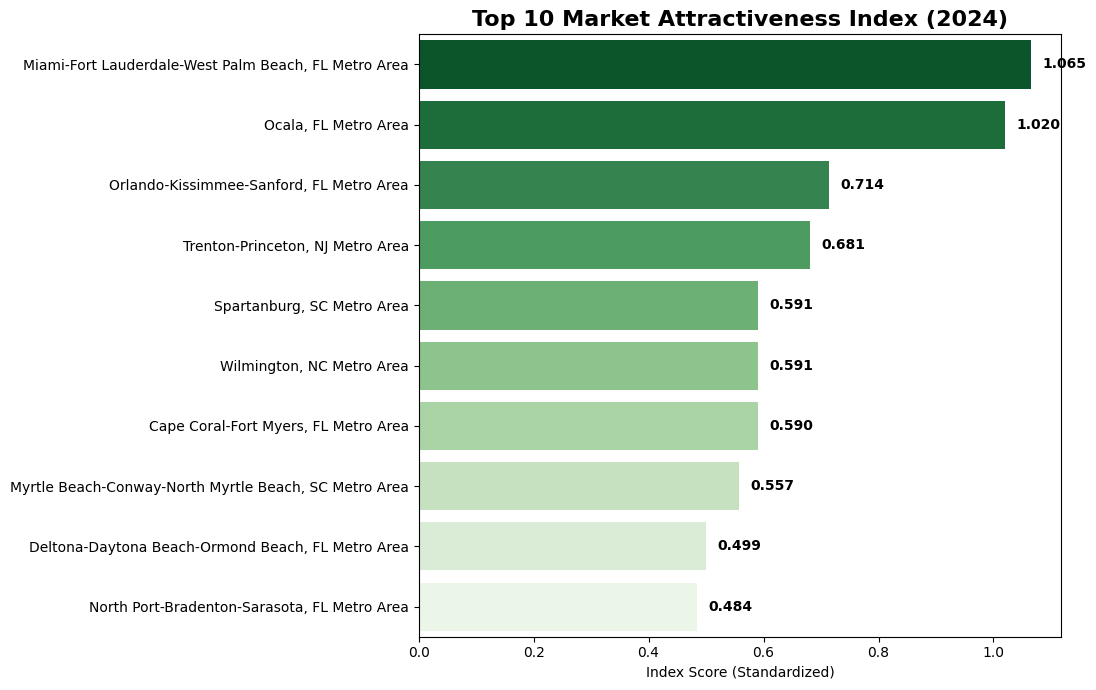

In [48]:
# Top 10 bar chart
top10 = ranking.head(10)

plt.figure(figsize=(11, 7))
sns.barplot(data=top10, x='Index_Score', y='msa_name', palette='Greens_r')

for idx, val in enumerate(top10['Index_Score']):
    plt.text(val + 0.02, idx, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.title(f'Top 10 Market Attractiveness Index ({latest_year})', fontsize=16, fontweight='bold')
plt.xlabel('Index Score (Standardized)')
plt.ylabel('')
plt.tight_layout()
plt.show()


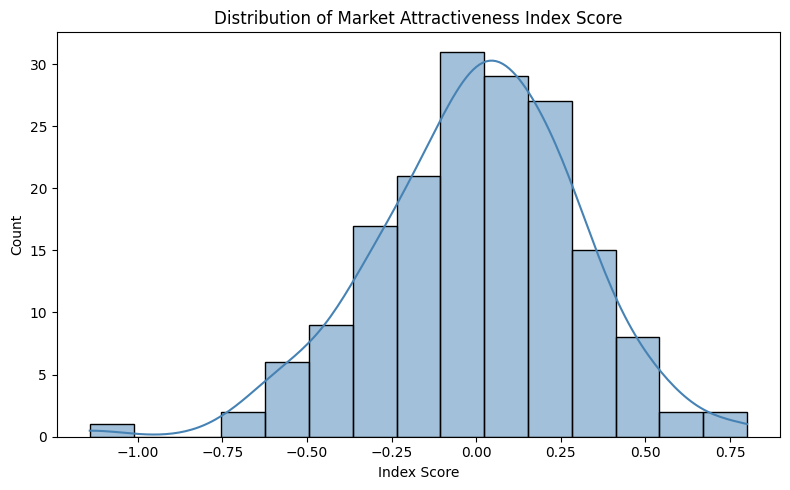

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(ranking['Index_Score'], kde=True, color='steelblue')
plt.title('Distribution of Market Attractiveness Index Score')
plt.xlabel('Index Score')
plt.tight_layout()
plt.show()


In [ ]:
!pip install xlsxwriter -q
import ipywidgets as widgets
from IPython.display import display

index_cols = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']

export_df = ranking[['msa_name', 'msa_code'] + index_cols].copy()
export_df.columns = ['MSA Name', 'MSA Code',
                     'Economic (20%)', 'Stability (15%)', 'Supply (15%)',
                     'Pricing (15%)', 'Valuation (15%)', 'Regulatory (20%)', 'Index Score']

output_file = f'MSA_Index_Ranking_{latest_year}.xlsx'

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    export_df.to_excel(writer, index=False, sheet_name='Index_Ranking')
    wb = writer.book
    ws = writer.sheets['Index_Ranking']
    header_fmt = wb.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
    num_fmt    = wb.add_format({'num_format': '0.000'})
    for col_num, col_name in enumerate(export_df.columns):
        ws.write(0, col_num, col_name, header_fmt)
    ws.set_column('A:A', 40)
    ws.set_column('B:I', 16, num_fmt)
    ws.freeze_panes(1, 0)

def download_click(b):
    files.download(output_file)
    print(f'Downloaded {output_file}')

btn = widgets.Button(description='Download Excel', button_style='success',
                     layout=widgets.Layout(width='200px', height='40px'))
btn.on_click(download_click)
print(f'Excel file "{output_file}" ready.')
display(btn)


ModuleNotFoundError: No module named 'ipywidgets'

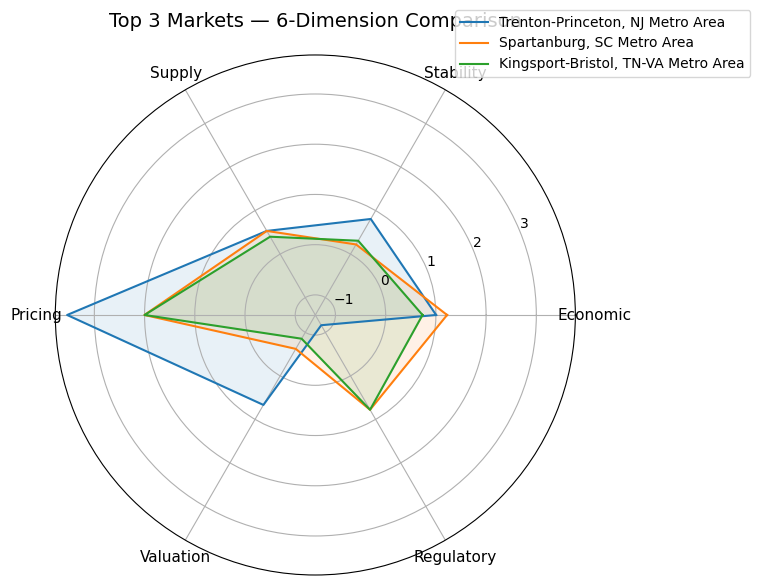

In [ ]:
# Top 3 MSAs — 6-Dimension Radar Chart
top3 = ranking.head(3)

categories = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Regulatory_Index']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for i in range(3):
    values = top3.iloc[i][categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=top3.iloc[i]['msa_name'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_Index', '').replace('_', ' ') for c in categories], fontsize=11)
plt.title('Top 3 Markets — 6-Dimension Comparison', size=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()


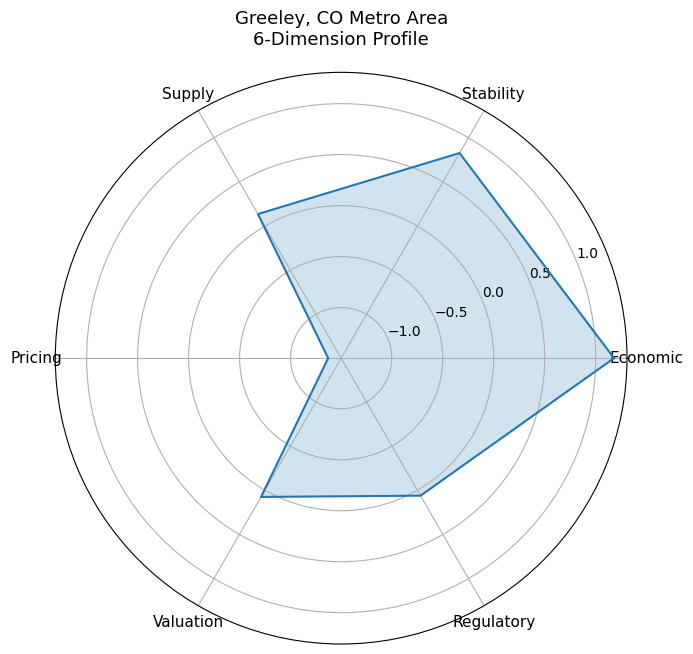

In [ ]:
# ================================
# Single MSA Radar Chart (by msa_code)
# ================================

# Change this to the msa_code you want to visualize
target_code = '24540'

categories = ['Economic_Index', 'Stability_Index', 'Supply_Index',
              'Pricing_Index', 'Valuation_Index', 'Regulatory_Index']

msa_data = df_scaled[df_scaled['msa_code'].astype(str) == str(target_code)]

if msa_data.empty:
    print(f'msa_code {target_code} not found. Available codes:')
    print(df_scaled['msa_code'].unique()[:10])
else:
    msa_name = msa_data.iloc[0]['msa_name']
    values   = msa_data.iloc[0][categories].tolist()

    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_Index', '').replace('_', ' ') for c in categories], fontsize=11)
    plt.title(f'{msa_name}\n6-Dimension Profile', size=13, pad=20)
    plt.tight_layout()
    plt.show()


zzy 4.13:下面这一块代码我没有改。

In [ ]:
# ================================
# EXPORT TO JSON FOR WEB APPLICATION
# ================================
import json

# Prepare output data
output_data = {
    'stats': {
        'year': latest_year,
        'total_msa_count': len(df_scaled),
        'scoring_system': '6-Dimensional Index (Economic, Stability, Supply, Pricing, Valuation, Regulatory)',
    },
    'msas': []
}

# Merge scoring data with raw factors
export_cols = ['msa_code', 'msa_name', 'year',
               'Employment_Rate', 'Pop_Growth', 'Income_Growth', 'Employment_Growth',
               'Rent_Growth', 'Rent_to_Income_Ratio', 'Implied_Value',
               'Vacancy_Rate', 'Market_Tightness', 'Value_Potential',
               'Diff_Effective_Rate', 'Cap Spread', 'Average HERS Index Score',
               'Economic_Index', 'Stability_Index', 'Supply_Index',
               'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']

# Get raw factor data for latest year
factor_latest = factor_df[factor_df['year'] == latest_year].copy()

# Merge with scores
merged = pd.merge(factor_latest, df_scaled[['msa_code', 'Economic_Index', 'Stability_Index',
                                                'Supply_Index', 'Pricing_Index', 'Valuation_Index',
                                                'Capital_Index', 'Index_Score']],
                 on='msa_code', how='left')

# Add basic census data
census_latest = testing_data[testing_data['year'] == latest_year][
    ['msa_code', 'Total_Population', 'Median_Gross_Rent', 'Median_Household_Income', 'Median_House_Value']
].rename(columns={
    'Median_Gross_Rent': 'Median_Rent',
    'Median_Household_Income': 'Median_Income',
    'Median_House_Value': 'Median_Home_Value'
})

merged = pd.merge(merged, census_latest, on='msa_code', how='left')

# Convert to JSON
for idx, row in merged.iterrows():
    msa_dict = {col: (float(row[col]) if pd.notna(row[col]) and not isinstance(row[col], (int, str)) else
                      int(row[col]) if col in ['msa_code', 'year'] and pd.notna(row[col]) else
                      row[col])
                 for col in export_cols if col in row.index}
    # Ensure numeric fields are properly formatted
    for key in ['Employment_Rate', 'Pop_Growth', 'Income_Growth', 'Employment_Growth',
                'Rent_Growth', 'Rent_to_Income_Ratio', 'Implied_Value', 'Vacancy_Rate',
                'Market_Tightness', 'Value_Potential', 'Economic_Index', 'Stability_Index',
                'Supply_Index', 'Pricing_Index', 'Valuation_Index', 'Capital_Index', 'Index_Score']:
        if key in msa_dict and pd.notna(msa_dict[key]):
            msa_dict[key] = float(msa_dict[key])
    output_data['msas'].append(msa_dict)

# Save to JSON
output_file = '/Users/ac/Desktop/Capstone Project/Capstone-Coding/docs/data/sample_data_new.json'
with open(output_file, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f'✓ JSON exported to {output_file}')
print(f'  Total MSAs: {len(output_data["msas"])}')
print(f'  Sample (first MSA):')   
if output_data['msas']:
    print(f"    {output_data['msas'][0]['msa_name']}")
    print(f"    Employment_Rate: {output_data['msas'][0].get('Employment_Rate', 'N/A')}")